# General data exploration
think of this as a scratch pad.

Ongoing development related to scripts may be transferred to a named notebook

In [ ]:
import geopandas as gpd
from pathlib import Path
import httpx
from jsna_climate_and_environment.geography.places import read_gdb

2026-04-13 11:08:29.496 | INFO     | jsna_climate_and_environment.config:<module>:38 - ROOT_DIR: D:\nmolkent\code\jsna-climate-and-environment


<Axes: >

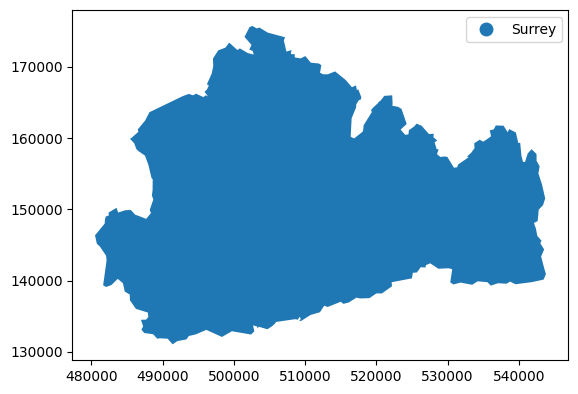

In [4]:
surrey_county = read_gdb("county")
surrey_county.plot(column="county_name", legend=True)

In [5]:
surrey_county

,county_code,county_name,source_url,geometry
0,E10000030,Surrey,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((502587.903 175761.398, 503199...."


<Axes: >

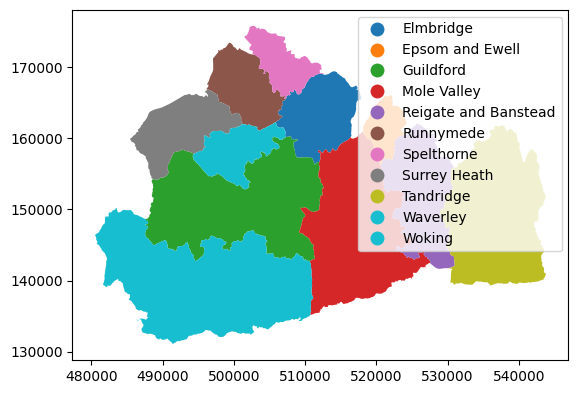

In [6]:
surrey_districts =  read_gdb("districts")
surrey_districts.plot(column="district_name", legend=True)

In [7]:
surrey_districts

,district_code,district_name,source_url,geometry
0,E07000207,Elmbridge,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((514102.898 169389.002, 514126...."
1,E07000208,Epsom and Ewell,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((522153.95 166034.05, 522160.35..."
2,E07000209,Guildford,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((505811.301 160132.902, 505820 ..."
3,E07000210,Mole Valley,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((518097.399 160868.801, 518106...."
4,E07000211,Reigate and Banstead,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((525705.397 162028.299, 525703...."
5,E07000212,Runnymede,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((499990.701 172802.295, 500000...."
6,E07000213,Spelthorne,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((503199.299 175411.098, 503325...."
7,E07000214,Surrey Heath,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((496870.6 166574.9, 496879.5 16..."
8,E07000215,Tandridge,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((537677 161787.3, 537679.7 1617..."
9,E07000216,Waverley,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((483734.4 149584.101, 483745.10..."


<Axes: >

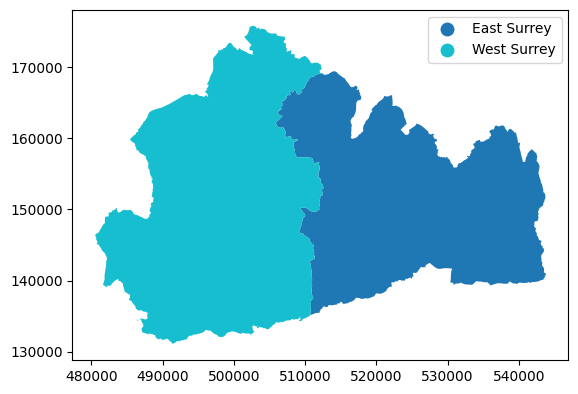

In [8]:
surrey_lgr =  read_gdb("lgr")
surrey_lgr.plot(column="lgr_name", legend=True)

In [9]:
surrey_lgr

,lgr_name,lgr_code,source_url,geometry
0,East Surrey,SCC_EAST,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((527526.302 142467.199, 527521...."
1,West Surrey,SCC_WEST,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((483853.401 149576.104, 483891...."


<Axes: >

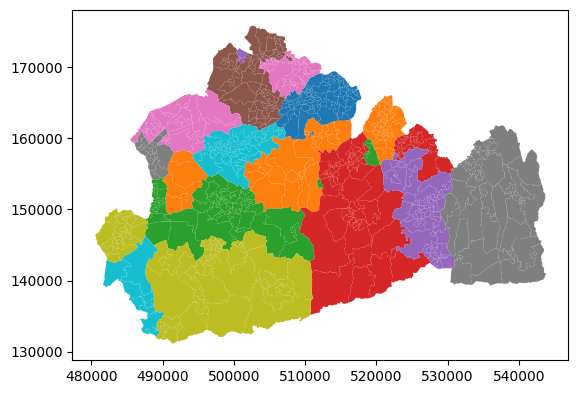

In [11]:
surrey_lsoas = read_gdb("lsoa")
surrey_lsoas.plot(column="lsoa21_name")

In [12]:
surrey_lsoas

,lsoa21_code,lsoa21_name,source_url,geometry
0,E01030296,Elmbridge 015A,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((517080.666 164767.597, 517080...."
1,E01030297,Elmbridge 015B,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((515036 164690.752, 515038.813 ..."
2,E01030298,Elmbridge 015C,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((516150.144 164498.2, 516200.87..."
3,E01030299,Elmbridge 015D,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((515282.144 163601.63, 515307.6..."
4,E01030300,Elmbridge 017A,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((511271.573 160957.78, 511265.0..."
...,...,...,...,...
716,E01035360,Reigate and Banstead 016G,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((527848.04 144674.199, 527859 1..."
717,E01035361,Reigate and Banstead 018F,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((528530.714 143218.357, 528543...."
718,E01035362,Reigate and Banstead 018G,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((528763 143199.817, 528761.044 ..."
719,E01035363,Tandridge 002E,https://services1.arcgis.com/ESMARspQHYMw9BZ9/...,"MULTIPOLYGON (((533975.062 158553, 533976.895 ..."


In [ ]:
def stream_file(response: httpx.Response, download_location: Path):
    response.raise_for_status()
    download_location.parent.mkdir(exist_ok=True, parents=True)
    with download_location.open("wb") as file:
        for chunk in response.iter_bytes():
            file.write(chunk)

<Axes: >

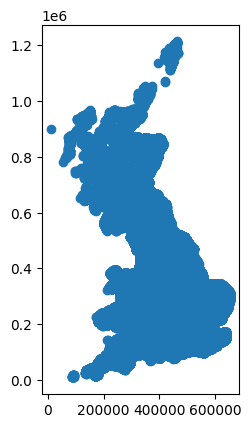

In [ ]:
def read_os_dataset(dataset_name, gpkg_filename: str, layer:int=0):
    root_dir = Path("data/os")
    root_dir.mkdir(exist_ok=True,parents=True)
    file_dir = root_dir / f"{dataset_name}.zip"
    if not file_dir.exists():
        # logger.info("downloading file...")
        with httpx.stream(
            "GET", 
            f"https://api.os.uk/downloads/v1/products/{dataset_name}/downloads?area=GB&format=GeoPackage&redirect",
            follow_redirects=True
        ) as response:
            stream_file(response, file_dir)
    
    return gpd.read_file(
        filename=f"{file_dir.as_posix()}!{gpkg_filename}", layer=layer  
    )
greenspace_access = read_os_dataset("OpenGreenspace", "Data/opgrsp_gb.gpkg", 0)
greenspace_access.plot()

In [ ]:
greenspace_polygons = read_os_dataset("OpenGreenspace", "Data/opgrsp_gb.gpkg", 1)
greenspace_polygons

,id,function,distinctive_name_1,distinctive_name_2,distinctive_name_3,distinctive_name_4,geometry
0,0D627D81-9D1C-45B3-9670-E9E46D4320BB,Public Park Or Garden,Herne Bay Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((616860.92 165983.07, 616860.15..."
1,1C4FD10E-2BBE-4535-ACF6-2316358DF47A,Other Sports Facility,Grove View Health and Care Hub and Apartments,None,None,None,"MULTIPOLYGON (((501789.27 222495.56, 501794.64..."
2,3585B3AA-E7EE-4E02-A9EA-C5E68C27B534,Public Park Or Garden,Arun Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((497925.39 101657.73, 497923.95..."
3,3B3400A5-C4D3-48B9-AC3D-58582A92A0FE,Public Park Or Garden,Bishopbriggs Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((263178.95 672492.24, 263185.7 ..."
4,3D6C4ACB-1515-80C3-E063-8ECAA00A8EB3,Allotments Or Community Growing Spaces,None,None,None,None,"MULTIPOLYGON (((303816.17 169712.3, 303805.48 ..."
...,...,...,...,...,...,...,...
165582,BC7FE2E5-6E33-4DF9-A168-0E22CDF9FF73,Public Park Or Garden,Holytown Crematorium and Memorial Gardens,None,None,None,"MULTIPOLYGON (((277117.72 660499.33, 277118.19..."
165583,C5BC4AB1-B446-4141-A792-C059EC405588,Other Sports Facility,Danderhall Library and Leisure Centre,None,None,None,"MULTIPOLYGON (((330716.49 669814.53, 330667.22..."
165584,C7ACADF0-01AC-47B2-BD30-E0C3223F2E57,Public Park Or Garden,Northumberland Woodland Burial and Crematorium,None,None,None,"MULTIPOLYGON (((417739.82 597699.1, 417742.13 ..."
165585,DF2DE585-11D8-40B9-B274-2BF8584C5994,Public Park Or Garden,None,None,None,None,"MULTIPOLYGON (((536108.39 174727.68, 536100.05..."


<Axes: >

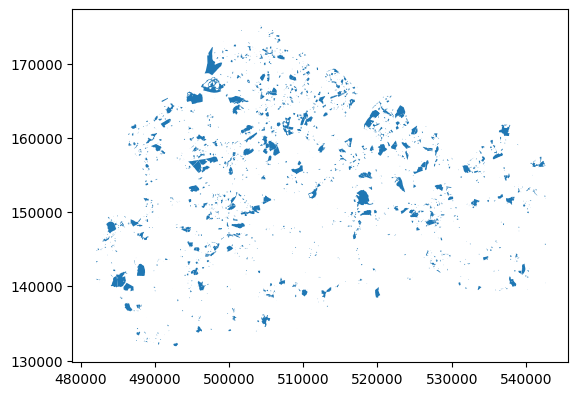

In [ ]:
surrey_greenspace = greenspace_polygons.clip(surrey_county.geometry)
surrey_greenspace.plot()

In [ ]:
from matplotlib.colors import Normalize, LinearSegmentedColormap

<Axes: >

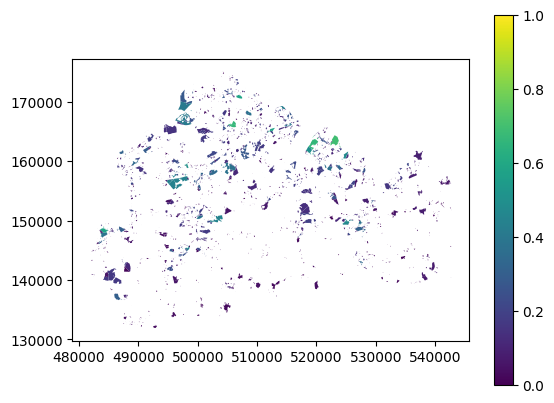

In [ ]:
greenspace_in_lsoa = surrey_lsoas.geometry.intersection(surrey_greenspace.geometry.union_all())
greenspace_by_lsoa = surrey_lsoas[["LSOA21CD", "geometry"]].copy()
greenspace_by_lsoa["geometry"] = greenspace_in_lsoa
greenspace_by_lsoa["greenspace_density"] = greenspace_in_lsoa.area / surrey_lsoas.geometry.area
greenspace_by_lsoa = greenspace_by_lsoa.explode()
greenspace_by_lsoa = greenspace_by_lsoa[~greenspace_by_lsoa.is_empty & (greenspace_by_lsoa.geom_type != "Point")]
fig, ax = plt.subplots(1, 1)
greenspace_by_lsoa.plot(
    column="greenspace_density",
    legend=True,
    ax=ax,
    norm=Normalize(0,1),
    # cmap=LinearSegmentedColormap.from_list("", ["linen", "yellowgreen", "green", "darkgreen"])
)

In [ ]:
rivers = read_os_dataset("OpenRivers", "Data/oprvrs_gb.gpkg", 1)
rivers

,id,flow_direction,length,fictitious,form,watercourse_name,watercourse_name_alternative,start_node,end_node,geometry
0,73E1A217-C5BF-41E3-AA17-F969F5181E04,in direction,18.0,0,tidalRiver,None,None,6B77D6D2-B9B2-4FBE-AEA3-8A801079B231,35806C2B-E01E-4CB8-9767-3D6F86302713,"LINESTRING (463513.13 1211952.73, 463524.68 12..."
1,A44E2603-3307-4555-9604-3DAB8AA308C6,in direction,1009.0,0,inlandRiver,None,None,8FA84F8B-71CE-4626-8CEC-5964B94D34CC,D2571525-C2FD-4A2A-8236-7E938081B3E7,"LINESTRING (463559.61 1212995.55, 463604.12 12..."
2,83332CB1-EC9C-486C-AC88-0BE480176548,in direction,1352.0,0,inlandRiver,Burn of Norwick,None,5EEC6ADE-DF7B-4B72-BE47-C78F810C39BF,C3EE6BFE-7B45-4251-951D-4F2A3BB4BBC3,"LINESTRING (463963.5 1214106.5, 463952.5 12140..."
3,83C8021E-C7EF-4C2B-955A-3365D9DDF079,in direction,165.0,0,inlandRiver,None,None,5CF9C9E6-F0D3-4421-81AD-989455DD490C,5EEC6ADE-DF7B-4B72-BE47-C78F810C39BF,"LINESTRING (463993.19 1214238.57, 464010.7 121..."
4,58F9A511-A4BD-47F4-95C1-FE396F677E1B,in direction,27.0,0,inlandRiver,None,None,D2571525-C2FD-4A2A-8236-7E938081B3E7,1740F423-BAF7-4B61-AE72-743CC7BE3D60,"LINESTRING (464188.6 1212433.5, 464188.38 1212..."
...,...,...,...,...,...,...,...,...,...,...
192733,7EB00B29-3123-49FD-AD44-8340BB33F404,in direction,232.0,0,inlandRiver,None,None,04E1EF1B-618C-4BBF-A345-5C783A897E02,5EE99987-0230-4BBB-BDFC-70C96B139C28,"LINESTRING (142067.43 33538.46, 142050.77 3352..."
192734,3355B2D8-576B-430D-BE7D-382B926F0FE7,in direction,732.0,0,inlandRiver,None,None,937C50B0-E3C8-4006-8C05-299E0D3B7334,1FEFFD80-26F0-4BB0-880A-63DE127AD449,"LINESTRING (145424.72 35748.27, 145428.69 3571..."
192735,EE3F229D-62CF-4877-B57F-ADE942804371,in direction,568.0,0,inlandRiver,None,None,03D09FEA-9748-456F-9B92-F0B657624E1C,56037488-0E8B-4A60-8934-7EE1339012EB,"LINESTRING (139378.67 35449.55, 139335.43 3551..."
192736,AC23A1FC-7C84-48AF-9E49-EDD08442AAE1,in direction,733.0,0,inlandRiver,None,None,2F32710C-3CF5-4EEF-B5F8-7D4CFAE7429B,3C77BFD9-D00F-40A5-9D5B-D916B99638CD,"LINESTRING (143070.37 37026.09, 143047.38 3703..."


<Axes: >

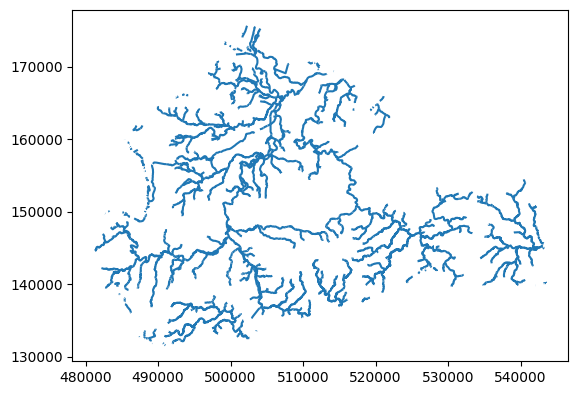

In [ ]:
surrey_rivers = rivers.clip(surrey_county.geometry)
surrey_rivers.plot()

[Text(0.5, 1.0, 'Surrey rivers')]

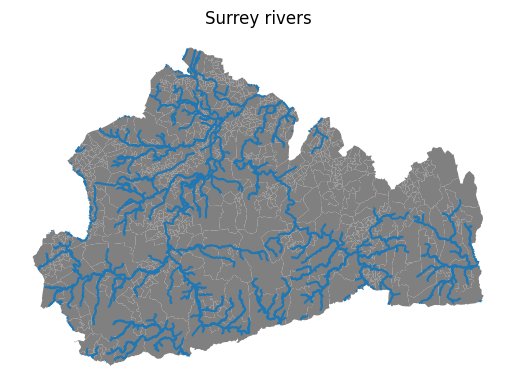

In [ ]:
ax = surrey_rivers.plot()
surrey_lsoas.plot(
    ax=ax,
    color="grey"
)
ax.set_axis_off()
ax.set(
    title="Surrey rivers"
)